[seed 0] ok
[seed 1] ok
[seed 2] ok
[seed 3] ok
[seed 4] ok
[seed 5] ok
[seed 6] ok
[seed 7] ok
[seed 8] ok
[seed 9] ok
[seed 10] ok
[seed 11] ok
[seed 12] ok
[seed 13] ok
[seed 14] ok
[seed 15] ok
[seed 16] ok
[seed 17] ok
[seed 18] ok
[seed 19] ok


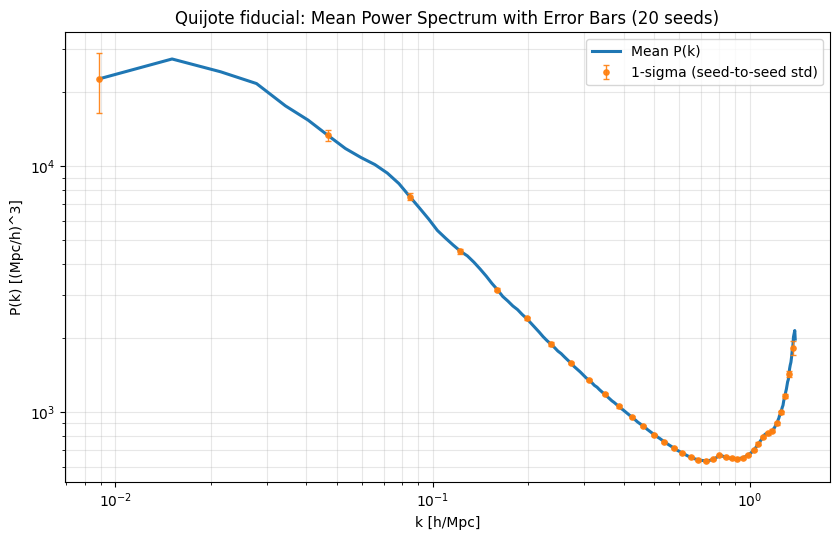

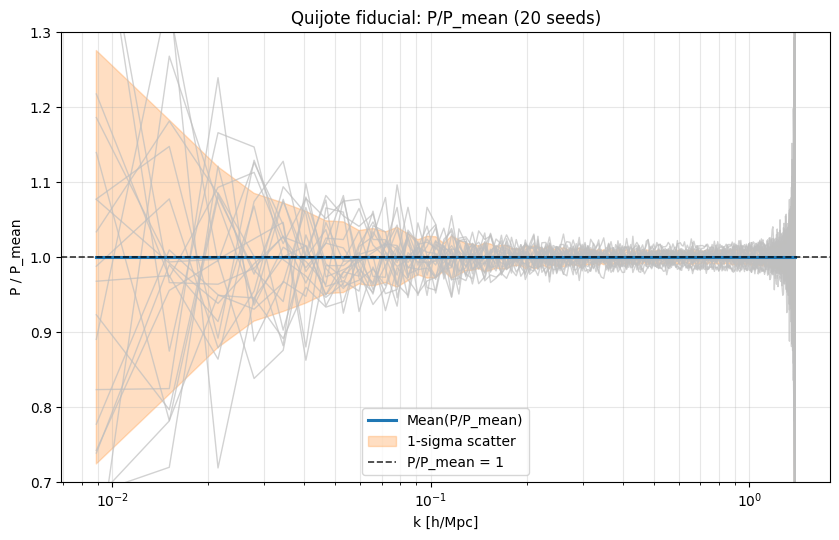

[summary] success seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [1]:
from pathlib import Path
import os
import sys
import importlib.util

# 强制覆盖坏的默认插件目录，避免 h5py 读 hdf5 时报 plugin path 错误
os.environ["HDF5_PLUGIN_PATH"] = "/tmp/hdf5_plugins"
Path(os.environ["HDF5_PLUGIN_PATH"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

# 按 2LPT.ipynb 的方式：直接复用 tests/2LPT.py 的工具函数
two_lpt_file = Path("/global/homes/l/liuyh15/WorkSpace/DDDF/tests/2LPT.py")
if not two_lpt_file.exists():
    raise FileNotFoundError(f"2LPT file not found: {two_lpt_file}")

module_name = "two_lpt_local"
spec = importlib.util.spec_from_file_location(module_name, str(two_lpt_file))
if spec is None or spec.loader is None:
    raise RuntimeError("Failed to create module spec for 2LPT.py")
n2 = importlib.util.module_from_spec(spec)
sys.modules[module_name] = n2
spec.loader.exec_module(n2)

CATALOG_NAME = "fiducial"
ROOT_BASE = Path("/pscratch/sd/l/liuyh15/Quijote") / CATALOG_NAME
SEEDS = list(range(20))
GRID = 256
MAX_FILES = None
ERROR_TYPE = "std"  # "std" or "sem"

k_ref = None
pk_rows = []
ok_seeds = []
fail_rows = []

for seed_i in SEEDS:
    try:
        root_i = ROOT_BASE / str(seed_i)
        paths = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)

        cfg = n2.load_param_config(paths.param_file)
        box = float(cfg["box"])

        z0_pos, _ = n2._load_hdf5_particles(paths.snapshot_z0, max_files=MAX_FILES)
        delta_z0 = n2._paint_cic_density(z0_pos, box=box, grid=GRID)

        try:
            import Pk_library as PKL  # type: ignore

            pk_obj = PKL.Pk(delta_z0, box, axis=0, MAS="CIC", threads=16, verbose=False)
            k_i = np.asarray(pk_obj.k3D, dtype=np.float64)
            pk_i = np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
        except Exception:
            k_i, pk_i = n2._pk_numpy(delta_z0, box)

        # 2LPT 里 box/坐标默认是 kpc/h，这里统一转换到 h/Mpc 与 (Mpc/h)^3
        k_i = k_i * 1000.0
        pk_i = pk_i / 1.0e9

        m = np.isfinite(k_i) & np.isfinite(pk_i) & (k_i > 0) & (pk_i > 0)
        k_i = k_i[m]
        pk_i = pk_i[m]

        if k_ref is None:
            k_ref = k_i.copy()
            pk_interp = pk_i.copy()
        else:
            pk_interp = np.interp(k_ref, k_i, pk_i, left=np.nan, right=np.nan)

        if np.isfinite(pk_interp).sum() < 10:
            raise RuntimeError("Too few finite P(k) bins after interpolation")

        pk_rows.append(pk_interp)
        ok_seeds.append(seed_i)
        print(f"[seed {seed_i}] ok")
    except Exception as e:
        fail_rows.append((seed_i, str(e)))
        print(f"[seed {seed_i}] fail: {e}")

if not pk_rows:
    raise RuntimeError("No valid seed power spectra were collected.")

pk_arr = np.asarray(pk_rows, dtype=np.float64)
valid_col = np.all(np.isfinite(pk_arr), axis=0)
k_plot = k_ref[valid_col]
pk_use = pk_arr[:, valid_col]

pk_mean = np.mean(pk_use, axis=0)
pk_std = np.std(pk_use, axis=0, ddof=1) if pk_use.shape[0] > 1 else np.zeros_like(pk_mean)
pk_sem = pk_std / np.sqrt(pk_use.shape[0]) if pk_use.shape[0] > 0 else np.zeros_like(pk_mean)
err = pk_std if ERROR_TYPE.lower() == "std" else pk_sem
err_label = "1-sigma (seed-to-seed std)" if ERROR_TYPE.lower() == "std" else "SEM"

step = max(1, len(k_plot) // 35)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(k_plot, pk_mean, lw=2.2, color="tab:blue", label="Mean P(k)")
ax.errorbar(
    k_plot[::step],
    pk_mean[::step],
    yerr=err[::step],
    fmt="o",
    ms=3.8,
    lw=1.0,
    capsize=2.2,
    color="tab:orange",
    alpha=0.9,
    label=err_label,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k [h/Mpc]")
ax.set_ylabel("P(k) [(Mpc/h)^3]")
ax.set_title(f"Quijote {CATALOG_NAME}: Mean Power Spectrum with Error Bars ({len(ok_seeds)} seeds)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

# 新增：绘制每个 seed 的 P/P_mean
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(pk_mean[None, :] > 0, pk_use / pk_mean[None, :], np.nan)

ratio_mean = np.nanmean(ratio, axis=0)
ratio_std = np.nanstd(ratio, axis=0, ddof=1) if ratio.shape[0] > 1 else np.zeros_like(ratio_mean)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for i, seed_i in enumerate(ok_seeds):
    ax.plot(k_plot, ratio[i], color="0.75", lw=1.0, alpha=0.7)

ax.plot(k_plot, ratio_mean, color="tab:blue", lw=2.2, label="Mean(P/P_mean)")
ax.fill_between(
    k_plot,
    ratio_mean - ratio_std,
    ratio_mean + ratio_std,
    color="tab:orange",
    alpha=0.25,
    label="1-sigma scatter",
)
ax.axhline(1.0, color="black", lw=1.2, ls="--", alpha=0.8, label="P/P_mean = 1")

ax.set_xscale("log")
ax.set_xlabel("k [h/Mpc]")
ax.set_ylabel("P / P_mean")
ax.set_title(f"Quijote {CATALOG_NAME}: P/P_mean ({len(ok_seeds)} seeds)")
ax.set_ylim(0.7, 1.3)
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

print(f"[summary] success seeds: {ok_seeds}")
if fail_rows:
    print("[summary] failed seeds:")
    for s, msg in fail_rows:
        print(f"  - seed {s}: {msg}")

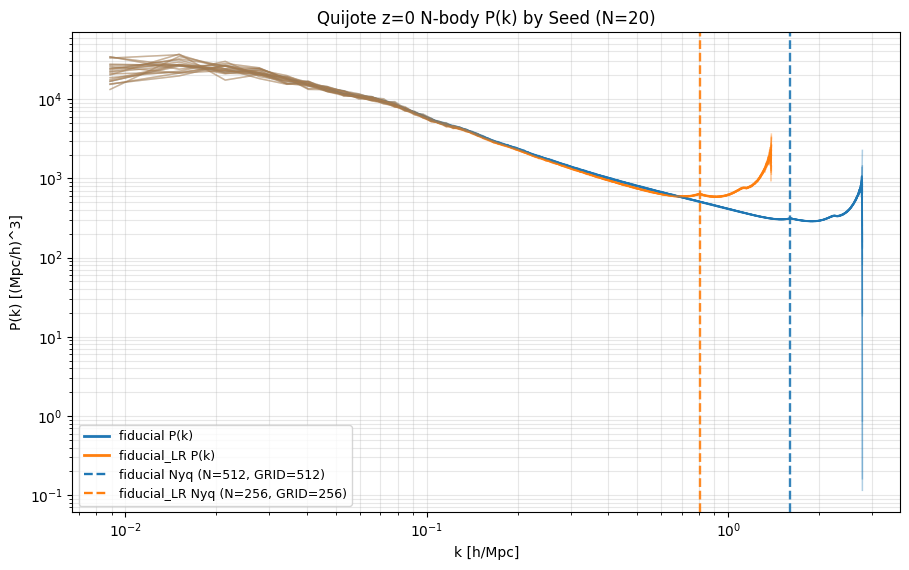

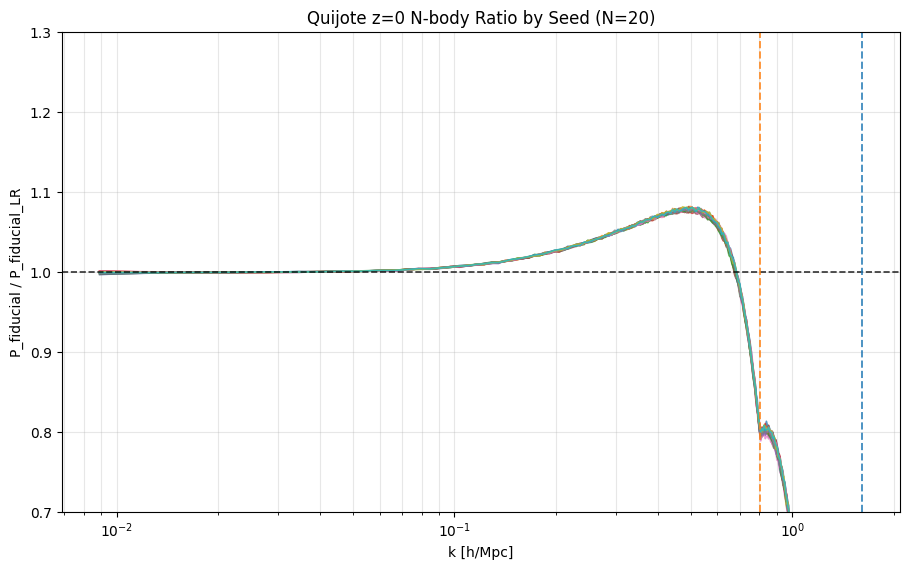

common valid seeds (20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
fiducial Nyq ~ 1.608 h/Mpc (N=512, GRID=512)
fiducial_LR Nyq ~ 0.804 h/Mpc (N=256, GRID=256)
FFT Nyq check: A=1.608, B=0.804 h/Mpc


In [7]:
# 绘制 z=0 的 nbody 功率谱：逐 seed 绝对值 + 逐 seed 比值，并标注 Nyquist 位置
from pathlib import Path

CATALOG_A = "fiducial"
CATALOG_B = "fiducial_LR"
ROOT_QUJ = Path("/pscratch/sd/l/liuyh15/Quijote")

seeds_use = globals().get("SEEDS", list(range(20)))
max_files_use = globals().get("MAX_FILES", None)

if "n2" not in globals():
    raise RuntimeError("请先运行第 1 个 cell（需要加载 tests/2LPT.py 到 n2）。")

def collect_pk_by_seed(catalog_name, seeds, max_files):
    root_base = ROOT_QUJ / catalog_name
    data = {}
    failed = []

    for seed_i in seeds:
        root_i = root_base / str(seed_i)
        try:
            paths = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)
            cfg = n2.load_param_config(paths.param_file)
            box = float(cfg["box"])

            z0_pos, _ = n2._load_hdf5_particles(paths.snapshot_z0, max_files=max_files)

            # particle Nyquist 来自粒子分辨率；FFT 网格强制与粒子分辨率一致
            npart = int(z0_pos.shape[0])
            n1d = int(round(npart ** (1.0 / 3.0)))
            grid_fft = int(n1d)

            k_nyq_particle = np.pi * n1d / box * 1000.0
            k_nyq_fft = np.pi * grid_fft / box * 1000.0

            delta_z0 = n2._paint_cic_density(z0_pos, box=box, grid=grid_fft)

            try:
                import Pk_library as PKL  # type: ignore

                pk_obj = PKL.Pk(delta_z0, box, axis=0, MAS="CIC", threads=16, verbose=False)
                k_i = np.asarray(pk_obj.k3D, dtype=np.float64)
                pk_i = np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
            except Exception:
                k_i, pk_i = n2._pk_numpy(delta_z0, box)

            # 与第 1 个 cell 保持单位一致
            k_i = k_i * 1000.0
            pk_i = pk_i / 1.0e9

            m = np.isfinite(k_i) & np.isfinite(pk_i) & (k_i > 0) & (pk_i > 0)
            k_i = k_i[m]
            pk_i = pk_i[m]

            if k_i.size < 10:
                raise RuntimeError("too few valid bins")

            data[seed_i] = {
                "k": k_i,
                "pk": pk_i,
                "k_nyq_particle": float(k_nyq_particle),
                "k_nyq_fft": float(k_nyq_fft),
                "n1d": int(n1d),
                "grid_fft": int(grid_fft),
            }
        except Exception as e:
            failed.append((seed_i, str(e)))

    return data, failed

data_a, fail_a = collect_pk_by_seed(CATALOG_A, seeds_use, max_files_use)
data_b, fail_b = collect_pk_by_seed(CATALOG_B, seeds_use, max_files_use)

common_seeds = sorted(set(data_a.keys()) & set(data_b.keys()))
if not common_seeds:
    raise RuntimeError("fiducial 与 fiducial_LR 没有共同可用 seed。")

knyq_part_a = float(np.median([data_a[s]["k_nyq_particle"] for s in common_seeds]))
knyq_part_b = float(np.median([data_b[s]["k_nyq_particle"] for s in common_seeds]))
knyq_fft_a = float(np.median([data_a[s]["k_nyq_fft"] for s in common_seeds]))
knyq_fft_b = float(np.median([data_b[s]["k_nyq_fft"] for s in common_seeds]))
n1d_a = int(round(np.median([data_a[s]["n1d"] for s in common_seeds])))
n1d_b = int(round(np.median([data_b[s]["n1d"] for s in common_seeds])))
gfft_a = int(round(np.median([data_a[s]["grid_fft"] for s in common_seeds])))
gfft_b = int(round(np.median([data_b[s]["grid_fft"] for s in common_seeds])))

# 图 1：逐 seed 绝对功率谱（不插值，直接使用各自原始 k 网格）
fig, ax = plt.subplots(figsize=(9.2, 5.8))
for seed_i in common_seeds:
    k_a = data_a[seed_i]["k"]
    pk_a = data_a[seed_i]["pk"]
    k_b = data_b[seed_i]["k"]
    pk_b = data_b[seed_i]["pk"]
    ax.plot(k_a, pk_a, color="tab:blue", lw=1.1, alpha=0.35)
    ax.plot(k_b, pk_b, color="tab:orange", lw=1.1, alpha=0.35)

# 不同分辨率的 Nyquist（当前设置下 particle 与 FFT Nyquist 在各自 catalog 内重合）
ax.axvline(knyq_part_a, color="tab:blue", ls="--", lw=1.7, alpha=0.9)
ax.axvline(knyq_part_b, color="tab:orange", ls="--", lw=1.7, alpha=0.9)

# 图例代理线
ax.plot([], [], color="tab:blue", lw=2.0, label=f"{CATALOG_A} P(k)")
ax.plot([], [], color="tab:orange", lw=2.0, label=f"{CATALOG_B} P(k)")
ax.plot([], [], color="tab:blue", ls="--", lw=1.7, label=f"{CATALOG_A} Nyq (N={n1d_a}, GRID={gfft_a})")
ax.plot([], [], color="tab:orange", ls="--", lw=1.7, label=f"{CATALOG_B} Nyq (N={n1d_b}, GRID={gfft_b})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k [h/Mpc]")
ax.set_ylabel("P(k) [(Mpc/h)^3]")
ax.set_title(f"Quijote z=0 N-body P(k) by Seed (N={len(common_seeds)})")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# 图 2：逐 seed 比值 P_fiducial / P_fiducial_LR（计算比值需插值到同一 k）
fig, ax = plt.subplots(figsize=(9.2, 5.8))
for seed_i in common_seeds:
    k_a = data_a[seed_i]["k"]
    pk_a = data_a[seed_i]["pk"]
    k_b = data_b[seed_i]["k"]
    pk_b = data_b[seed_i]["pk"]
    pk_b_on_a = np.interp(k_a, k_b, pk_b, left=np.nan, right=np.nan)
    m = np.isfinite(pk_b_on_a) & np.isfinite(pk_a) & (pk_b_on_a > 0) & (pk_a > 0)
    if np.count_nonzero(m) < 10:
        continue
    ax.plot(k_a[m], pk_a[m] / pk_b_on_a[m], lw=1.2, alpha=0.75)

ax.axhline(1.0, color="black", lw=1.2, ls="--", alpha=0.8)
ax.axvline(knyq_part_a, color="tab:blue", ls="--", lw=1.4, alpha=0.8)
ax.axvline(knyq_part_b, color="tab:orange", ls="--", lw=1.4, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("k [h/Mpc]")
ax.set_ylabel("P_fiducial / P_fiducial_LR")
ax.set_title(f"Quijote z=0 N-body Ratio by Seed (N={len(common_seeds)})")
ax.set_ylim(0.7, 1.3)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"common valid seeds ({len(common_seeds)}): {common_seeds}")
print(f"{CATALOG_A} Nyq ~ {knyq_part_a:.3f} h/Mpc (N={n1d_a}, GRID={gfft_a})")
print(f"{CATALOG_B} Nyq ~ {knyq_part_b:.3f} h/Mpc (N={n1d_b}, GRID={gfft_b})")
print(f"FFT Nyq check: A={knyq_fft_a:.3f}, B={knyq_fft_b:.3f} h/Mpc")
if fail_a:
    print(f"{CATALOG_A} failed seeds: {[s for s, _ in fail_a]}")
if fail_b:
    print(f"{CATALOG_B} failed seeds: {[s for s, _ in fail_b]}")